In [14]:
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [15]:
con = duckdb.connect("../data/db/financial_data.duckdb")

prices = con.execute("select * from raw_prices").df()
macro  = con.execute("select * from macro_features").df()
feat   = con.execute("select * from features_daily").df()
labels = con.execute("select * from labels_regime").df()

for name, df in {
    "prices": prices,
    "macro": macro,
    "features": feat,
    "labels": labels,
}.items():
    print(f"{name}: {df.shape}")


prices: (12194, 9)
macro: (4189, 11)
features: (8799, 52)
labels: (17523, 5)


In [16]:
feat["date"] = pd.to_datetime(feat["date"])

feat.groupby("ticker").agg(
    start=("date", "min"),
    end=("date", "max"),
    n=("date", "count")
)

,start,end,n
ticker,,,
BTC-USD,2014-10-15,2026-01-09,2933
TLT,2014-10-15,2026-01-09,2933
^GSPC,2014-10-15,2026-01-09,2933


In [17]:
weekend_rows = feat[feat["date"].dt.weekday >= 5]
len(weekend_rows)

0

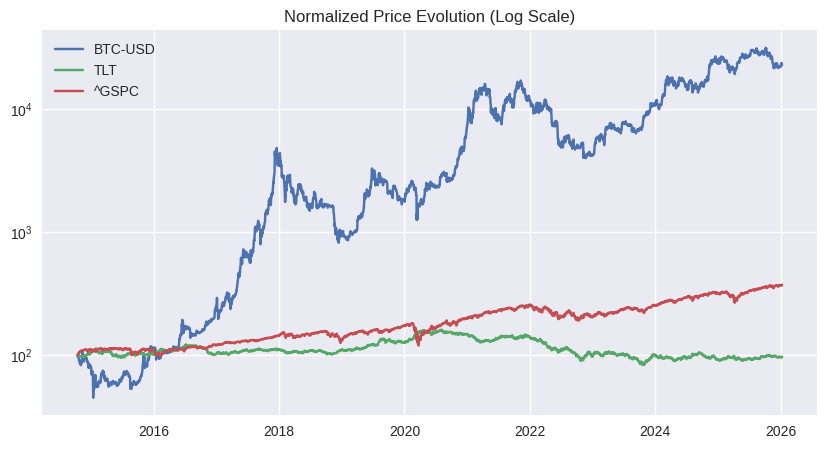

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

for t, g in feat.groupby("ticker"):
    base = g.iloc[0]["close"]
    ax.plot(g["date"], g["close"] / base * 100, label=t)

ax.set_yscale("log")
ax.set_title("Normalized Price Evolution (Log Scale)")
ax.legend()
plt.show()


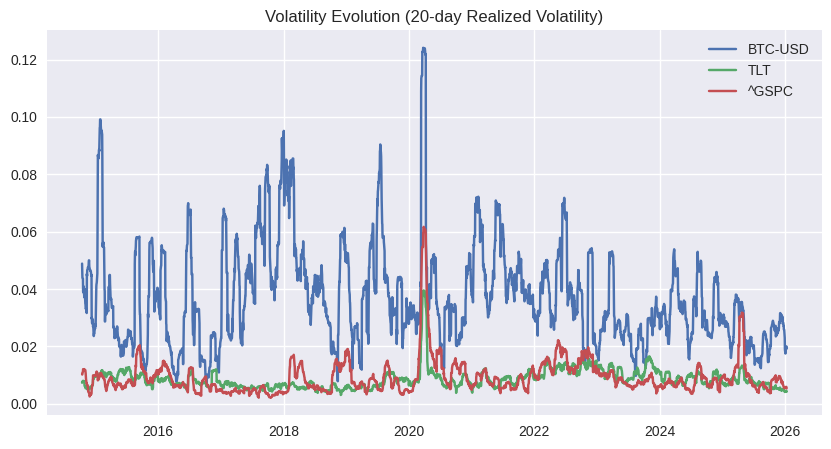

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

for t, g in feat.groupby("ticker"):
    ax.plot(g["date"], g["rv_20"], label=t)

ax.set_title("Volatility Evolution (20-day Realized Volatility)")
ax.legend()
plt.show()


In [20]:
macro.columns
macro["date"] = pd.to_datetime(macro["date"])
cols = ["vix", "net_liquidity", "m2", "rrp", "tga", "fed_assets"]

for col in cols:
    print(f"Not null values in {col}: {macro[col].notna().sum()} / {len(macro)}")
    print(f"Max value in {col}: {macro[col].max()}")
    print(f"Min value in {col}: {macro[col].min()}")

Not null values in vix: 4188 / 4189
Max value in vix: 82.69
Min value in vix: 9.14
Not null values in net_liquidity: 4030 / 4189
Max value in net_liquidity: 8703963.22
Min value in net_liquidity: 2229793.82
Not null values in m2: 4189 / 4189
Max value in m2: 22298.0
Min value in m2: 8477.7
Not null values in rrp: 4030 / 4189
Max value in rrp: 2553.716
Min value in rrp: 0.0
Not null values in tga: 4186 / 4189
Max value in tga: 1816687.0
Min value in tga: 11666.0
Not null values in fed_assets: 4186 / 4189
Max value in fed_assets: 8965487.0
Min value in fed_assets: 2235304.0


<Axes: title={'center': 'Net Liquidity over Time'}, xlabel='date'>

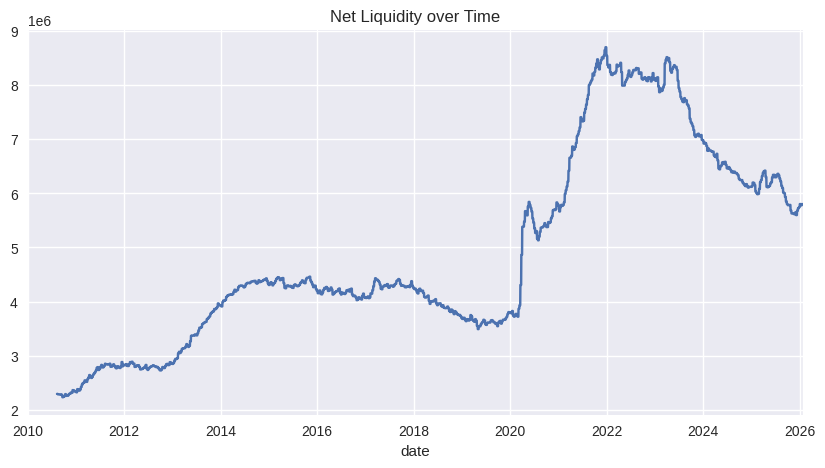

In [21]:
macro.set_index('date')['net_liquidity'].plot(figsize=(10, 5), title="Net Liquidity over Time")

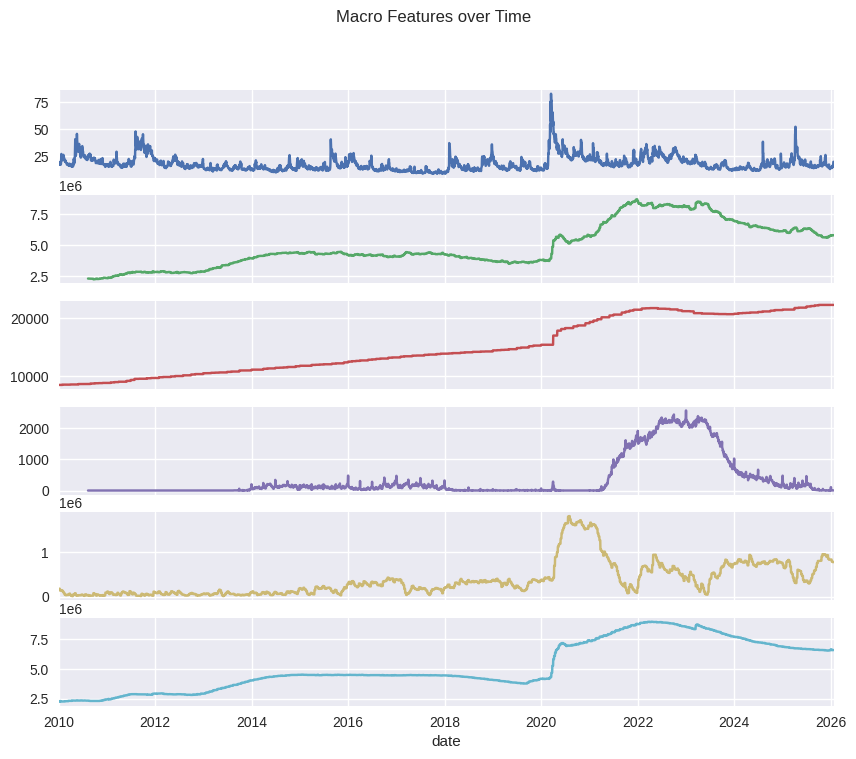

In [23]:
macro[["date"] + cols].set_index("date").plot(
    subplots=True,
    figsize=(10, 8),
    title="Macro Features over Time",
    legend=False
)
plt.show()

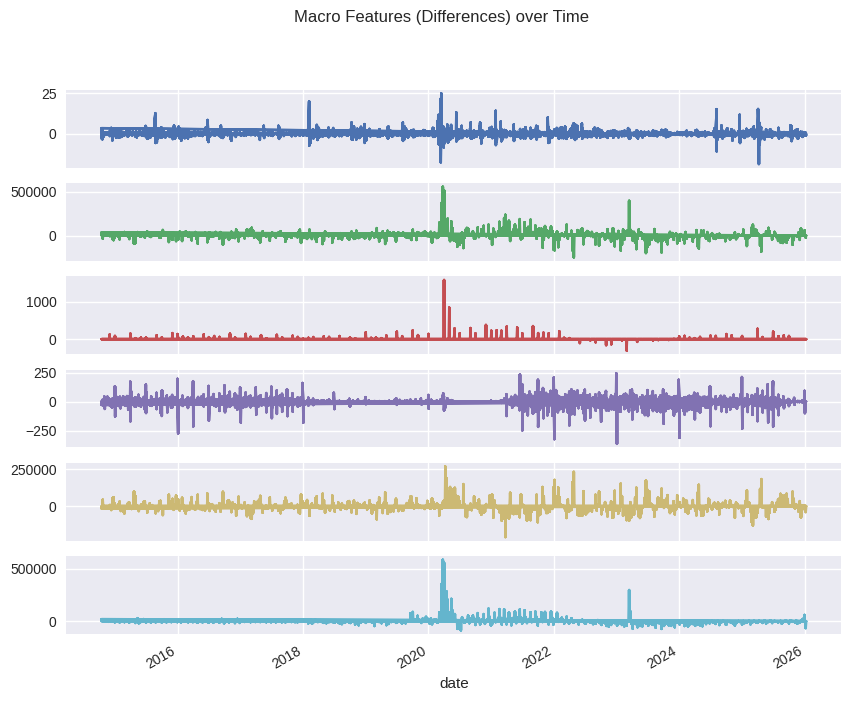

In [24]:
diff_cols = [c + "_diff" for c in cols if c + "_diff" in feat.columns]

feat[["date"] + diff_cols].set_index("date").plot(
    subplots=True,
    figsize=(10, 8),
    title="Macro Features (Differences) over Time",
    legend=False
)
plt.show()

In [25]:
def corr_table(ticker, horizon=20):
    g = feat[feat["ticker"] == ticker].copy()
    cols = [
        "vix_diff",
        "net_liquidity_diff",
        "m2_diff",
        "rrp_diff",
        "tga_diff",
    ]
    return g[cols + ["rv_20"]].corr()["rv_20"].sort_values(ascending=False)

for t in feat["ticker"].unique():
    print("\n", t)
    display(corr_table(t))



 BTC-USD


rv_20                 1.000000
net_liquidity_diff    0.120894
m2_diff               0.076984
rrp_diff              0.022441
tga_diff             -0.003432
vix_diff             -0.015694
Name: rv_20, dtype: float64


 TLT


rv_20                 1.000000
net_liquidity_diff    0.149859
m2_diff               0.093787
tga_diff              0.031908
rrp_diff             -0.001850
vix_diff             -0.056490
Name: rv_20, dtype: float64


 ^GSPC


rv_20                 1.000000
net_liquidity_diff    0.142303
m2_diff               0.107956
tga_diff              0.056782
rrp_diff              0.011346
vix_diff             -0.055863
Name: rv_20, dtype: float64

In [26]:
def cross_corr(x, y, lags=60):
    out = {}
    for lag in range(-lags, lags + 1):
        out[lag] = x.corr(y.shift(lag))
    return pd.Series(out)


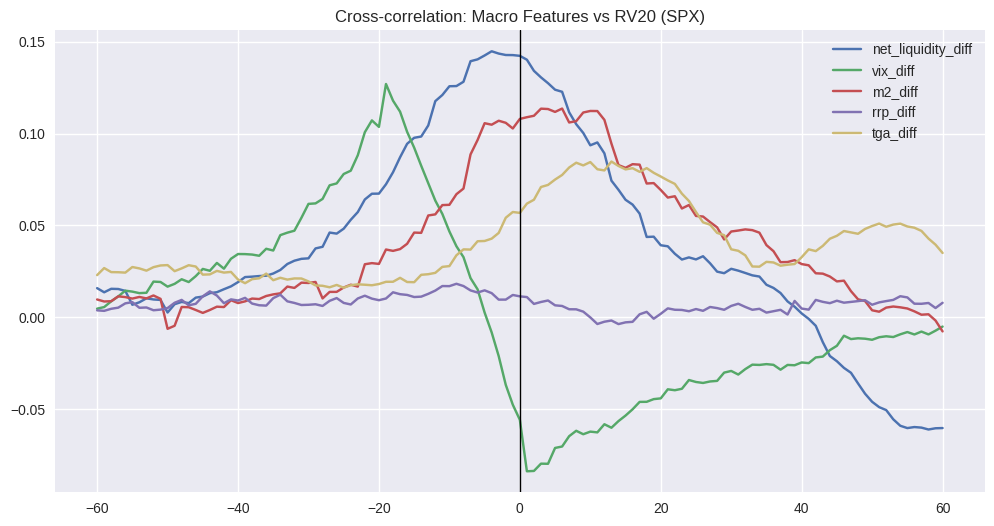

In [33]:
g = feat[feat["ticker"] == "^GSPC"]

for macro in ["net_liquidity_diff", "vix_diff", "m2_diff", "rrp_diff", "tga_diff"]:
    cc = cross_corr(
        g[macro],
        g["rv_20"],
        lags=60
    )

    cc.plot(figsize=(12, 6), label=macro)
plt.axvline(0, color="black", lw=1)
plt.legend()
plt.title("Cross-correlation: Macro Features vs RV20 (SPX)")
plt.show()


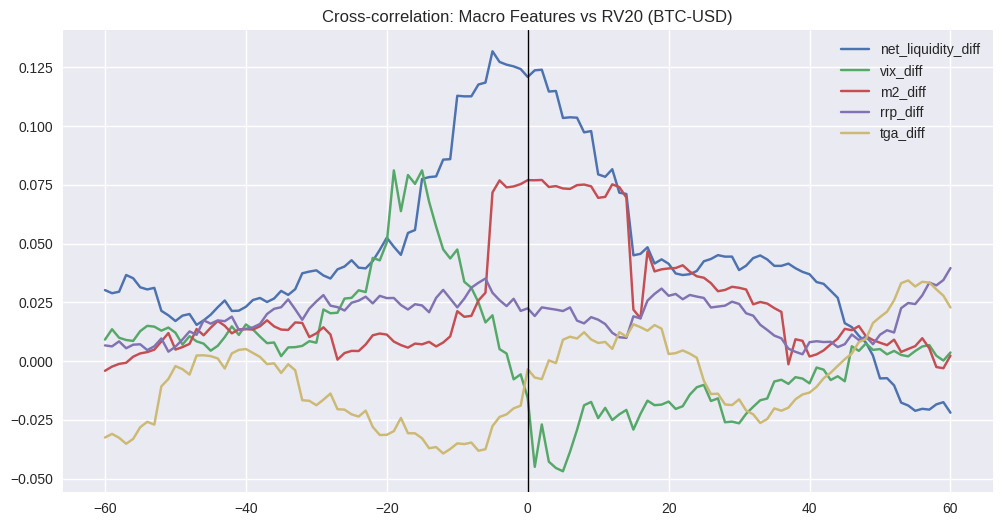

In [34]:
g = feat[feat["ticker"] == "BTC-USD"]

for macro in ["net_liquidity_diff", "vix_diff", "m2_diff", "rrp_diff", "tga_diff"]:
    cc = cross_corr(
        g[macro],
        g["rv_20"],
        lags=60
    )

    cc.plot(figsize=(12, 6), label=macro)
plt.axvline(0, color="black", lw=1)
plt.legend()
plt.title("Cross-correlation: Macro Features vs RV20 (BTC-USD)")
plt.show()


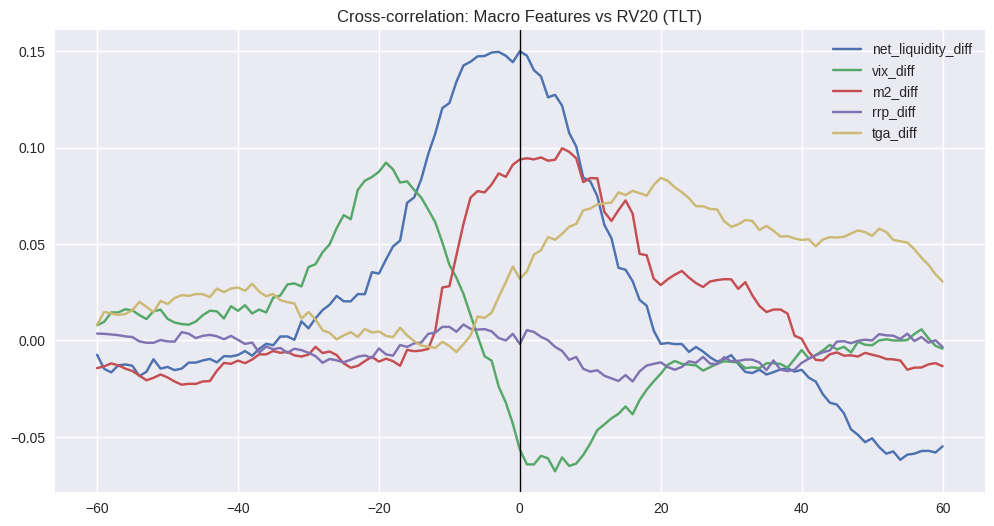

In [35]:
g = feat[feat["ticker"] == "TLT"]

for macro in ["net_liquidity_diff", "vix_diff", "m2_diff", "rrp_diff", "tga_diff"]:
    cc = cross_corr(
        g[macro],
        g["rv_20"],
        lags=60
    )

    cc.plot(figsize=(12, 6), label=macro)
plt.axvline(0, color="black", lw=1)
plt.legend()
plt.title("Cross-correlation: Macro Features vs RV20 (TLT)")
plt.show()
